# StreamablePandasModule Demo

This notebook demonstrates:
1. Creating a Hamilton module using Hamilton plugins
2. Using StreamablePandasModule to wrap it with lazy execution
3. Executing with lazy frames using dr.execute

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import polars as pl
import pandas as pd
from hamilton.htypes import Parallelizable, Collect

## Step 1: Create a Hamilton module using Hamilton plugins

In [2]:
%load_ext hamilton.plugins.jupyter_magic

/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [3]:
import os
os.environ["PATH"] = "/opt/miniconda/envs/spockappdev/bin:/opt/miniconda/condabin:/Users/cp371651/.nvm/versions/node/v20.11.0/bin:/Users/cp371651/.kube/plugins:/opt/homebrew/opt/openjdk@17/bin:/Users/cp371651/.rd/bin:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/usr/local/sbin:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/Users/cp371651/.vscode/extensions/ms-python.debugpy-2025.18.0-darwin-arm64/bundled/scripts/noConfigScripts:/opt/homebrew/bin:/opt/homebrew/opt/fzf/bin"

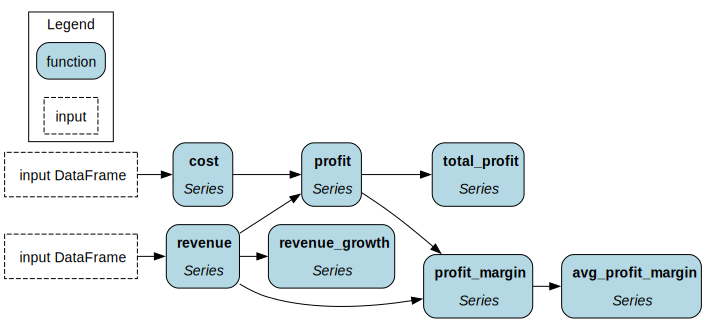

In [5]:
%%cell_to_module -m financial_metrics --display --rebuild-drivers

import pandas as pd
from hamilton.htypes import Parallelizable, Collect

def revenue(input: pd.DataFrame) -> pd.Series:
    """Extract revenue column."""
    return input["revenue"]

def cost(input: pd.DataFrame) -> pd.Series:
    """Extract cost column."""
    return input["cost"]

def profit(revenue: pd.Series, cost: pd.Series) -> pd.Series:
    """Calculate profit as revenue minus cost."""
    return revenue - cost

def profit_margin(profit: pd.Series, revenue: pd.Series) -> pd.Series:
    """Calculate profit margin as profit divided by revenue."""
    return (profit / revenue) * 100

def revenue_growth(revenue: pd.Series) -> pd.Series:
    """Calculate rolling 3-period revenue growth."""
    return revenue.pct_change(periods=3) * 100

def total_profit(profit: pd.Series) -> pd.Series:
    """Calculate total profit (scalar)."""
    return profit * 2

def avg_profit_margin(profit_margin: pd.Series) -> pd.Series:
    """Calculate average profit margin (scalar)."""
    return profit_margin / 2

## Step 2: Create sample data

In [6]:
# Create sample financial data
data = {
    "revenue": [1000.0, 1100.0, 1200.0, 1300.0, 1150.0, 1250.0, 1400.0, 1350.0],
    "cost": [600.0, 650.0, 720.0, 780.0, 690.0, 750.0, 840.0, 810.0],
    "period": ["2023-Q1", "2023-Q2", "2023-Q3", "2023-Q4", 
               "2024-Q1", "2024-Q2", "2024-Q3", "2024-Q4"]
}

# Create polars LazyFrame
lf = pl.LazyFrame(data)
print("Sample data:")
lf.collect()

Sample data:


revenue,cost,period
f64,f64,str
1000.0,600.0,"""2023-Q1"""
1100.0,650.0,"""2023-Q2"""
1200.0,720.0,"""2023-Q3"""
1300.0,780.0,"""2023-Q4"""
1150.0,690.0,"""2024-Q1"""
1250.0,750.0,"""2024-Q2"""
1400.0,840.0,"""2024-Q3"""
1350.0,810.0,"""2024-Q4"""


## Step 3: Create StreamablePandasModule

In [ ]:
from decider.dag.expanders.streamable_pandas import StreamablePandasModule

# Create Hamilton builder with our financial_metrics module

# Define output schema for map_batches
output_schema = {
    "profit_margin": pl.Float64,
    "revenue_growth": pl.Float64,
    "total_profit": pl.Float64,
    "avg_profit_margin": pl.Float64,
}

# Create streamable pandas module
streamable_mod = StreamablePandasModule(
    external_input_name="financial_data",  # External parameter name
    internal_input_name="input",           # Internal parameter name that functions use
    output_node_name="financial_metrics",  # Name of output collection node
    output_columns=["profit_margin", "revenue_growth", "total_profit", "avg_profit_margin"],
    output_schema=output_schema,
    map_batches_kwargs={
        "validate_output_schema": True,
        "projection_pushdown": True
    }
).with_modules(financial_metrics).with_modules(financial_metrics).with_modules(financial_metrics)

print("StreamablePandasModule created successfully!")

StreamablePandasModule created successfully!


## Step 4: Build DeciderBuilder with StreamablePandasModule

In [8]:
from decider.dag.builder import DeciderBuilder

# Build the DeciderBuilder with our streamable module
dr = (
    DeciderBuilder()
    .with_config({})
    .include(streamable_mod)
    .build()
)

print(f"DeciderBuilder created: {dr}")
print(f"Available nodes: {list(dr.graph.nodes.keys())}")

DeciderBuilder created: <hamilton.driver.Driver object at 0x331841f90>
Available nodes: ['avg_profit_margin', 'cost', 'profit', 'profit_margin', 'revenue', 'revenue_growth', 'total_profit', 'input', 'financial_metrics', 'financial_data']


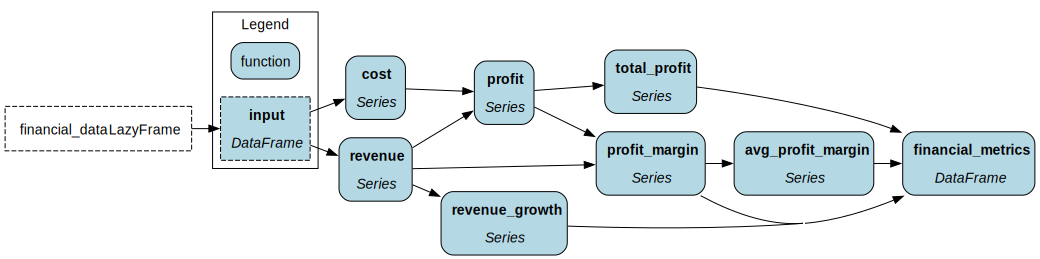

In [ ]:
dr 

## Step 5: Execute with LazyFrame

In [9]:
result = dr.raw_execute(
    ["avg_profit_margin"],  # Output node to execute
    inputs={"financial_data": lf}  # Pass the lazy frame as input
)

print("Execution result:")
print(result["avg_profit_margin"])

Driver.raw_execute will be deprecated by hamilton version: 2.0.0. This has become a private method and does not guarantee that all the adapters work correctly. For migration, see: Don't use this entry point for execution directly. Always go through `.execute()`or `.materialize()`..


Execution result:
LazyExecutionGraph(steps=OrderedDict([('input', Step(func=<function StreamablePandasModule._create_input_node.<locals>.input_func at 0x331838550>, inputs=['financial_data'])), ('revenue', Step(func=<function revenue at 0x1372c5fc0>, inputs=['input'])), ('cost', Step(func=<function cost at 0x32f7a1480>, inputs=['input'])), ('profit', Step(func=<function profit at 0x32f7a1090>, inputs=['revenue', 'cost'])), ('profit_margin', Step(func=<function profit_margin at 0x331838c10>, inputs=['profit', 'revenue'])), ('avg_profit_margin', Step(func=<function avg_profit_margin at 0x331838b80>, inputs=['profit_margin']))]), static_data={}, input_data=<LazyFrame at 0x32F77BB80>, input_name='financial_data')


In [11]:
# Execute with our lazy frame
result = dr.execute(
    ["financial_metrics"],  # Output node to execute
    inputs={"financial_data": lf}  # Pass the lazy frame as input
)

print("Execution result:")
print(result["financial_metrics"])
result["financial_metrics"].collect()

Execution result:
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

OPAQUE_PYTHON
  DF ["revenue", "cost", "period"]; PROJECT */3 COLUMNS


profit_margin,revenue_growth,total_profit,avg_profit_margin
f64,f64,f64,f64
40.0,null,800.0,20.0
40.909091,null,900.0,20.454545
40.0,null,960.0,20.0
40.0,30.0,1040.0,20.0
40.0,4.545455,920.0,20.0
40.0,4.166667,1000.0,20.0
40.0,7.692308,1120.0,20.0
40.0,17.391304,1080.0,20.0


## Step 6: Test with different data batches

In [11]:
# Create larger dataset to test batching
import random
random.seed(42)

large_data = {
    "revenue": [random.uniform(800, 1500) for _ in range(100)],
    "cost": [random.uniform(400, 900) for _ in range(100)],
    "period": [f"2020-Q{i%4+1}" for i in range(100)]
}

large_lf = pl.LazyFrame(large_data)
print(f"Large dataset shape: {large_lf.collect().shape}")

# Execute with larger dataset
large_result = dr.execute(
    ["financial_metrics"],
    inputs={"financial_data": large_lf}
)

print("\nLarge dataset result:")
print(large_result["financial_metrics"])

result["financial_metrics"].collect()

Large dataset shape: (100, 3)

Large dataset result:
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

OPAQUE_PYTHON
  DF ["revenue", "cost", "period"]; PROJECT */3 COLUMNS


profit_margin,revenue_growth,total_profit,avg_profit_margin
f64,f64,f64,f64
40.0,null,800.0,20.0
40.909091,null,900.0,20.454545
40.0,null,960.0,20.0
40.0,30.0,1040.0,20.0
40.0,4.545455,920.0,20.0
40.0,4.166667,1000.0,20.0
40.0,7.692308,1120.0,20.0
40.0,17.391304,1080.0,20.0


## Step 7: Demonstrate lazy execution efficiency

In [12]:
# Show that we can chain lazy operations before execution
filtered_lf = large_lf.filter(pl.col("revenue") > 1000)

print(f"Filtered dataset (revenue > 1000):")
filtered_result = dr.execute(
    ["financial_metrics"],
    inputs={"financial_data": filtered_lf}
)

print(filtered_result["financial_metrics"])
result["financial_metrics"].collect()

Filtered dataset (revenue > 1000):
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

OPAQUE_PYTHON
  FILTER [(col("revenue")) > (1000.0)]
  FROM
    DF ["revenue", "cost", "period"]; PROJECT */3 COLUMNS


profit_margin,revenue_growth,total_profit,avg_profit_margin
f64,f64,f64,f64
40.0,null,800.0,20.0
40.909091,null,900.0,20.454545
40.0,null,960.0,20.0
40.0,30.0,1040.0,20.0
40.0,4.545455,920.0,20.0
40.0,4.166667,1000.0,20.0
40.0,7.692308,1120.0,20.0
40.0,17.391304,1080.0,20.0


## Step 8: Inspect the lazy execution graph

In [13]:
# Let's inspect what happens during lazy execution
# First, let's see the node structure
for node_name, node in dr.graph.nodes.items():
    print(f"Node: {node_name}")
    print(f"  Type: {node.type}")
    print(f"  Inputs: {list(node.input_types.keys()) if node.input_types else 'None'}")
    print()

Node: avg_profit_margin
  Type: <class 'pandas.core.series.Series'>
  Inputs: ['profit_margin']

Node: cost
  Type: <class 'pandas.core.series.Series'>
  Inputs: ['input']

Node: profit
  Type: <class 'pandas.core.series.Series'>
  Inputs: ['revenue', 'cost']

Node: profit_margin
  Type: <class 'pandas.core.series.Series'>
  Inputs: ['profit', 'revenue']

Node: revenue
  Type: <class 'pandas.core.series.Series'>
  Inputs: ['input']

Node: revenue_growth
  Type: <class 'pandas.core.series.Series'>
  Inputs: ['revenue']

Node: total_profit
  Type: <class 'pandas.core.series.Series'>
  Inputs: ['profit']

Node: input
  Type: <class 'pandas.core.frame.DataFrame'>
  Inputs: ['financial_data']

Node: financial_metrics
  Type: <class 'pandas.core.frame.DataFrame'>
  Inputs: ['profit_margin', 'revenue_growth', 'total_profit', 'avg_profit_margin']

Node: financial_data
  Type: <class 'polars.lazyframe.frame.LazyFrame'>
  Inputs: None



## Summary

This notebook demonstrated:

1. **Hamilton Plugin Usage**: Created a financial metrics module using `%%cell_to_module` magic
2. **StreamablePandasModule Integration**: Wrapped the Hamilton module with lazy execution capabilities
3. **Lazy Frame Execution**: Used `dr.execute()` with polars LazyFrames as input
4. **Efficient Processing**: Showed how the lazy execution works with filtered data

The StreamablePandasModule successfully:
- Converted polars LazyFrames to pandas DataFrames for processing
- Applied lazy execution wrappers to build execution graphs
- Used `map_batches` for efficient polars processing
- Collected results into the specified output schema